# Week 2 Lab: Machine Learning Fundamentals — From Scratch to PyTorch

**Course:** Deep Learning (COE 443) — Istinye University

**Instructor:** Asst. Prof. Dr. Yigit Bekir Kaya

**Reference:** Goodfellow, Bengio, Courville — *Deep Learning*, Chapter 5

---

## Objectives

In this lab you will:

1. **Implement linear regression from scratch** using only NumPy — both the closed-form solution (Normal Equations) and gradient descent
2. **Implement logistic regression from scratch** using only NumPy — sigmoid, binary cross-entropy, and gradient descent
3. **Rewrite both models with PyTorch** using `torch.nn` and `torch.optim`, and see how autograd replaces manual gradient computation
4. **Explore key concepts** from the lecture: bias-variance tradeoff, regularization, and learning rate sensitivity

By the end, you will have a concrete, hands-on understanding of the core ML pipeline: **model → loss → optimize → evaluate**.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plot settings
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

NumPy version: 2.0.2
PyTorch version: 2.10.0+cu128
CUDA available: True


---

# Part 1: Linear Regression from Scratch (NumPy)

We start with the simplest supervised learning model: **linear regression**.

**Model:** $\hat{y} = \mathbf{w}^T \mathbf{x} + b$

**Loss:** Mean Squared Error — $\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$

We'll solve this two ways:
1. **Closed-form** (Normal Equations): $\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$
2. **Gradient Descent**: iteratively update weights in the direction of steepest descent

### 1.1 Generate Synthetic Data

We create data from a known linear relationship: $y = 3x + 7 + \varepsilon$ where $\varepsilon \sim \mathcal{N}(0, 2^2)$.

Knowing the true parameters ($w=3$, $b=7$) lets us verify that our model recovers them.

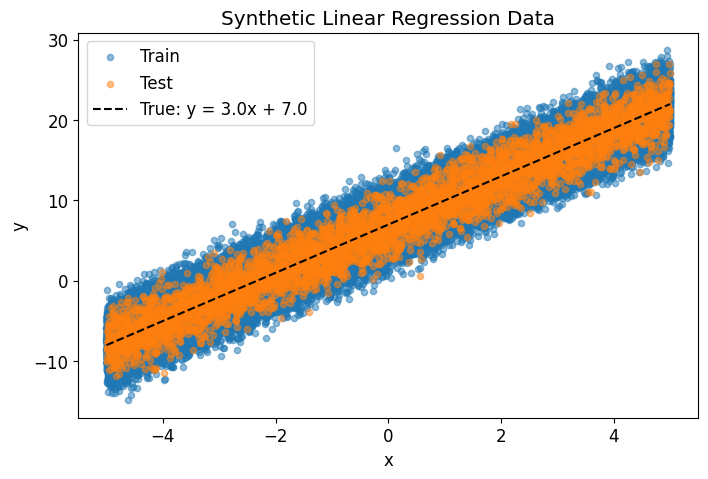

Training set: 100000 samples
Test set:     5000 samples


In [4]:
# True parameters
w_true = 3.0
b_true = 7.0
noise_std = 2.0

# Generate 100 training points and 50 test points
m_train = 100000
m_test = 5000

X_train = np.random.uniform(-5, 5, (m_train, 1))
y_train = w_true * X_train + b_true + np.random.randn(m_train, 1) * noise_std

X_test = np.random.uniform(-5, 5, (m_test, 1))
y_test = w_true * X_test + b_true + np.random.randn(m_test, 1) * noise_std

# Visualize
plt.scatter(X_train, y_train, alpha=0.5, label='Train', s=20)
plt.scatter(X_test, y_test, alpha=0.5, label='Test', s=20)
x_line = np.linspace(-5, 5, 100)
plt.plot(x_line, w_true * x_line + b_true, 'k--', label=f'True: y = {w_true}x + {b_true}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Synthetic Linear Regression Data')
plt.show()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

### 1.2 Closed-Form Solution (Normal Equations)

For linear regression, there is a direct analytical solution:

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

We augment $\mathbf{X}$ with a column of ones to absorb the bias term into $\mathbf{w}$.

In [5]:
# Augment X with a column of ones for the bias term
X_train_aug = np.hstack([X_train, np.ones((m_train, 1))])  # shape: (100, 2)
X_test_aug = np.hstack([X_test, np.ones((m_test, 1))])      # shape: (50, 2)

# Normal Equations: w = (X^T X)^{-1} X^T y
w_closed = np.linalg.inv(X_train_aug.T @ X_train_aug) @ X_train_aug.T @ y_train

print(f"Closed-form solution:")
print(f"  w = {w_closed[0, 0]:.4f}  (true: {w_true})")
print(f"  b = {w_closed[1, 0]:.4f}  (true: {b_true})")

# Compute MSE on both sets
y_pred_train = X_train_aug @ w_closed
y_pred_test = X_test_aug @ w_closed

mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_test = np.mean((y_pred_test - y_test) ** 2)

print(f"\nMSE (train): {mse_train:.4f}")
print(f"MSE (test):  {mse_test:.4f}")

Closed-form solution:
  w = 2.9942  (true: 3.0)
  b = 7.0046  (true: 7.0)

MSE (train): 3.9856
MSE (test):  4.0548


### 1.3 Gradient Descent Solution

In practice, we often can't use the closed-form solution (dataset too large, or model is nonlinear). Instead, we use **gradient descent**.

**Gradients of MSE:**

$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$

$$\frac{\partial \text{MSE}}{\partial b} = \frac{2}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

**Update rule:** $\theta \leftarrow \theta - \alpha \nabla_{\theta} \text{MSE}$

In [ ]:
def linear_regression_gd(X, y, lr=0.01, epochs=500):
    """Train linear regression using gradient descent.

    Args:
        X: input features, shape (m, 1)
        y: targets, shape (m, 1)
        lr: learning rate
        epochs: number of training iterations

    Returns:
        w, b: learned parameters
        losses: list of MSE values per epoch
    """
    m = X.shape[0]
    w = np.random.randn(1, 1) * 0.01  # small random init
    b = np.zeros((1, 1))
    losses = []

    for epoch in range(epochs):
        # Forward pass
        y_pred = X @ w + b            # (m, 1)
        error = y_pred - y            # (m, 1)

        # Compute loss
        mse = np.mean(error ** 2)
        losses.append(mse)

        # Compute gradients
        dw = (2 / m) * (X.T @ error)  # (1, 1)
        db = (2 / m) * np.sum(error)  # scalar

        # Update parameters
        w -= lr * dw
        b -= lr * db

    return w.item(), b.item(), losses


# Train
w_gd, b_gd, losses = linear_regression_gd(X_train, y_train, lr=0.01, epochs=500)

print(f"Gradient descent solution:")
print(f"  w = {w_gd:.4f}  (true: {w_true})")
print(f"  b = {b_gd:.4f}  (true: {b_true})")

In [ ]:
# Plot loss curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Training Loss Curve')
axes[0].set_yscale('log')

# Fit comparison
axes[1].scatter(X_train, y_train, alpha=0.4, s=20, label='Training data')
x_line = np.linspace(-5, 5, 100)
axes[1].plot(x_line, w_true * x_line + b_true, 'k--', label=f'True: y={w_true}x+{b_true}')
axes[1].plot(x_line, w_gd * x_line + b_gd, 'r-', label=f'GD: y={w_gd:.2f}x+{b_gd:.2f}')
axes[1].plot(x_line, w_closed[0, 0] * x_line + w_closed[1, 0], 'g--',
             label=f'Closed: y={w_closed[0, 0]:.2f}x+{w_closed[1, 0]:.2f}')
axes[1].legend()
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Linear Fit Comparison')

plt.tight_layout()
plt.show()

### 1.4 Exercise: Learning Rate Sensitivity

**Recall from the lecture (Slide 27):** The learning rate dramatically affects convergence.

Run gradient descent with three different learning rates and observe the effect.

In [ ]:
learning_rates = [0.001, 0.01, 0.1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, lr in zip(axes, learning_rates):
    _, _, lr_losses = linear_regression_gd(X_train, y_train, lr=lr, epochs=500)
    ax.plot(lr_losses)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f'lr = {lr}')
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)

plt.suptitle('Learning Rate Sensitivity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Question:** What happens if you set `lr = 1.0`? Try it. Why does training fail?

> *Hint: Think about the SGD update rule and what happens when the step is too large.*

---

# Part 2: Logistic Regression from Scratch (NumPy)

Now we move from regression (continuous output) to **binary classification** (discrete output).

**Model:** $\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b)$ where $\sigma(z) = \frac{1}{1 + e^{-z}}$

**Loss:** Binary Cross-Entropy — $\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$

**Why not MSE for classification?** MSE with sigmoid creates a non-convex loss surface with many local minima. Cross-entropy is convex for logistic regression and provides stronger gradients when the model is wrong.

### 2.1 Generate Synthetic Classification Data

We create two classes with 2D features using `sklearn.datasets.make_moons`, which generates a nonlinearly separable but visually clear dataset.

In [ ]:
from sklearn.datasets import make_classification

# Generate linearly separable data with some overlap
X_cls, y_cls = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, flip_y=0.1, class_sep=1.5, random_state=42
)
y_cls = y_cls.reshape(-1, 1).astype(np.float64)  # shape: (200, 1)

# Train/test split (manual — no sklearn dependency for splitting)
split = 150
X_cls_train, X_cls_test = X_cls[:split], X_cls[split:]
y_cls_train, y_cls_test = y_cls[:split], y_cls[split:]

# Visualize
plt.scatter(X_cls_train[y_cls_train.ravel() == 0, 0], X_cls_train[y_cls_train.ravel() == 0, 1],
            alpha=0.6, label='Class 0', s=30)
plt.scatter(X_cls_train[y_cls_train.ravel() == 1, 0], X_cls_train[y_cls_train.ravel() == 1, 1],
            alpha=0.6, label='Class 1', s=30)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.title('Binary Classification Data')
plt.show()

print(f"Train: {X_cls_train.shape[0]} samples, Test: {X_cls_test.shape[0]} samples")
print(f"Class balance (train): {y_cls_train.mean():.2f} positive")

### 2.2 Implement Sigmoid and Binary Cross-Entropy

In [ ]:
def sigmoid(z):
    """Numerically stable sigmoid function."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))


def binary_cross_entropy(y_true, y_pred):
    """Binary cross-entropy loss.

    Clips predictions to avoid log(0).
    """
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


# Quick sanity check
z_test = np.array([-10, -1, 0, 1, 10])
print("Sigmoid values:")
for z, s in zip(z_test, sigmoid(z_test)):
    print(f"  sigmoid({z:3d}) = {s:.6f}")

print(f"\nBCE(y=1, pred=0.9) = {binary_cross_entropy(np.array([1]), np.array([0.9])):.4f}")
print(f"BCE(y=1, pred=0.1) = {binary_cross_entropy(np.array([1]), np.array([0.1])):.4f}")
print("(Notice: wrong prediction → much higher loss)")

### 2.3 Train Logistic Regression with Gradient Descent

**Gradients of BCE with sigmoid:**

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

Note: These are the **same form** as linear regression gradients! The sigmoid is absorbed into the chain rule.

In [ ]:
def logistic_regression_gd(X, y, lr=0.1, epochs=1000):
    """Train logistic regression using gradient descent.

    Args:
        X: input features, shape (m, n_features)
        y: binary labels, shape (m, 1)
        lr: learning rate
        epochs: number of training iterations

    Returns:
        w: weight vector, shape (n_features, 1)
        b: bias scalar
        losses: list of BCE values per epoch
    """
    m, n = X.shape
    w = np.random.randn(n, 1) * 0.01
    b = 0.0
    losses = []

    for epoch in range(epochs):
        # Forward pass
        z = X @ w + b            # (m, 1)
        y_pred = sigmoid(z)      # (m, 1)

        # Compute loss
        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)

        # Compute gradients
        error = y_pred - y       # (m, 1)
        dw = (1 / m) * (X.T @ error)  # (n, 1)
        db = (1 / m) * np.sum(error)   # scalar

        # Update parameters
        w -= lr * dw
        b -= lr * db

    return w, b, losses


# Train
w_log, b_log, log_losses = logistic_regression_gd(X_cls_train, y_cls_train, lr=0.5, epochs=1000)

print(f"Learned weights: w1 = {w_log[0, 0]:.4f}, w2 = {w_log[1, 0]:.4f}, b = {b_log:.4f}")

In [ ]:
# Evaluate accuracy
def accuracy(X, y, w, b):
    y_pred = sigmoid(X @ w + b)
    y_class = (y_pred >= 0.5).astype(float)
    return np.mean(y_class == y)

train_acc = accuracy(X_cls_train, y_cls_train, w_log, b_log)
test_acc = accuracy(X_cls_test, y_cls_test, w_log, b_log)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy:     {test_acc:.2%}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(log_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].set_title('Logistic Regression Loss Curve')

# Decision boundary
ax = axes[1]
x_min, x_max = X_cls_train[:, 0].min() - 1, X_cls_train[:, 0].max() + 1
y_min, y_max = X_cls_train[:, 1].min() - 1, X_cls_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ w_log + b_log).reshape(xx.shape)

ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.6)
ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
ax.scatter(X_cls_train[y_cls_train.ravel() == 0, 0], X_cls_train[y_cls_train.ravel() == 0, 1],
           c='blue', alpha=0.6, s=20, label='Class 0')
ax.scatter(X_cls_train[y_cls_train.ravel() == 1, 0], X_cls_train[y_cls_train.ravel() == 1, 1],
           c='red', alpha=0.6, s=20, label='Class 1')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'Decision Boundary (Test acc: {test_acc:.2%})')
ax.legend()

plt.tight_layout()
plt.show()

---

# Part 3: Linear Regression with PyTorch

Now we rewrite Part 1 using PyTorch. Key differences:
- **No manual gradient computation** — `autograd` handles it
- **`nn.Linear`** replaces our manual weight matrix
- **`optim.SGD`** replaces our manual update rule

The training loop structure stays the same: **forward → loss → backward → update**

In [ ]:
# Convert NumPy data to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(f"Tensor shapes: X={X_train_t.shape}, y={y_train_t.shape}")

In [ ]:
# Define model
model_lr = nn.Linear(in_features=1, out_features=1)  # y = wx + b

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.SGD(model_lr.parameters(), lr=0.01)

# Training loop
pt_losses = []
for epoch in range(500):
    # Forward pass
    y_pred = model_lr(X_train_t)

    # Compute loss
    loss = criterion(y_pred, y_train_t)
    pt_losses.append(loss.item())

    # Backward pass (compute gradients)
    optimizer.zero_grad()   # reset gradients from previous step
    loss.backward()         # compute gradients via backpropagation

    # Update parameters
    optimizer.step()        # apply gradients

# Extract learned parameters
w_pt = model_lr.weight.item()
b_pt = model_lr.bias.item()

print(f"PyTorch solution:")
print(f"  w = {w_pt:.4f}  (true: {w_true})")
print(f"  b = {b_pt:.4f}  (true: {b_true})")

# Test MSE
with torch.no_grad():
    test_mse = criterion(model_lr(X_test_t), y_test_t).item()
print(f"  Test MSE: {test_mse:.4f}")

In [ ]:
# Compare all three approaches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(losses, label='NumPy GD', alpha=0.7)
axes[0].plot(pt_losses, label='PyTorch SGD', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Loss Curves: NumPy vs PyTorch')
axes[0].set_yscale('log')
axes[0].legend()

# Fit comparison
axes[1].scatter(X_train, y_train, alpha=0.3, s=15, label='Data')
x_line = np.linspace(-5, 5, 100)
axes[1].plot(x_line, w_true * x_line + b_true, 'k--', lw=2, label='True')
axes[1].plot(x_line, w_closed[0, 0] * x_line + w_closed[1, 0], 'g-', label='Closed-form')
axes[1].plot(x_line, w_gd * x_line + b_gd, 'r-', label='NumPy GD')
axes[1].plot(x_line, w_pt * x_line + b_pt, 'b--', label='PyTorch')
axes[1].legend()
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('All Solutions Compared')

plt.tight_layout()
plt.show()

print("All three methods converge to approximately the same solution!")

---

# Part 4: Logistic Regression with PyTorch

Now we rewrite Part 2 using PyTorch. The key mapping:

| From Scratch (NumPy) | PyTorch Equivalent |
|---|---|
| `w @ X + b` | `nn.Linear(2, 1)` |
| `sigmoid(z)` | `torch.sigmoid()` |
| `binary_cross_entropy()` | `nn.BCELoss()` |
| Manual gradient computation | `loss.backward()` |
| `w -= lr * dw` | `optim.SGD` + `optimizer.step()` |

In [ ]:
# Convert classification data to tensors
X_cls_train_t = torch.tensor(X_cls_train, dtype=torch.float32)
y_cls_train_t = torch.tensor(y_cls_train, dtype=torch.float32)
X_cls_test_t = torch.tensor(X_cls_test, dtype=torch.float32)
y_cls_test_t = torch.tensor(y_cls_test, dtype=torch.float32)

# Define model
model_log = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

# Loss and optimizer
criterion_bce = nn.BCELoss()
optimizer_log = optim.SGD(model_log.parameters(), lr=0.5)

# Training loop
pt_log_losses = []
for epoch in range(1000):
    # Forward
    y_pred = model_log(X_cls_train_t)
    loss = criterion_bce(y_pred, y_cls_train_t)
    pt_log_losses.append(loss.item())

    # Backward + update
    optimizer_log.zero_grad()
    loss.backward()
    optimizer_log.step()

# Evaluate
with torch.no_grad():
    train_preds = (model_log(X_cls_train_t) >= 0.5).float()
    test_preds = (model_log(X_cls_test_t) >= 0.5).float()
    pt_train_acc = (train_preds == y_cls_train_t).float().mean().item()
    pt_test_acc = (test_preds == y_cls_test_t).float().mean().item()

print(f"PyTorch Logistic Regression:")
print(f"  Training accuracy: {pt_train_acc:.2%}")
print(f"  Test accuracy:     {pt_test_acc:.2%}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves comparison
axes[0].plot(log_losses, label='NumPy', alpha=0.7)
axes[0].plot(pt_log_losses, label='PyTorch', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Logistic Regression: NumPy vs PyTorch')
axes[0].legend()

# PyTorch decision boundary
ax = axes[1]
grid_t = torch.tensor(grid, dtype=torch.float32)
with torch.no_grad():
    pt_probs = model_log(grid_t).numpy().reshape(xx.shape)

ax.contourf(xx, yy, pt_probs, levels=50, cmap='RdBu_r', alpha=0.6)
ax.contour(xx, yy, pt_probs, levels=[0.5], colors='black', linewidths=2)
ax.scatter(X_cls_test[y_cls_test.ravel() == 0, 0], X_cls_test[y_cls_test.ravel() == 0, 1],
           c='blue', alpha=0.6, s=30, edgecolors='k', lw=0.5, label='Class 0 (test)')
ax.scatter(X_cls_test[y_cls_test.ravel() == 1, 0], X_cls_test[y_cls_test.ravel() == 1, 1],
           c='red', alpha=0.6, s=30, edgecolors='k', lw=0.5, label='Class 1 (test)')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'PyTorch Decision Boundary (Test acc: {pt_test_acc:.2%})')
ax.legend()

plt.tight_layout()
plt.show()

---

# Part 5: Exploring Key Concepts

These exercises connect the lab to the core lecture topics from Chapter 5.

### 5.1 Bias-Variance Tradeoff (Polynomial Regression)

**From the lecture (Slides 9-11, 20):** Model capacity controls the bias-variance tradeoff.

We demonstrate this by fitting polynomials of increasing degree to the same data. Too simple → underfitting (high bias), too complex → overfitting (high variance).

In [ ]:
# Generate data from a quadratic function
np.random.seed(123)
n_poly = 30
X_poly = np.random.uniform(-3, 3, n_poly)
y_poly = 0.5 * X_poly**2 - X_poly + 1 + np.random.randn(n_poly) * 0.8  # true: 0.5x² - x + 1

X_poly_test = np.random.uniform(-3, 3, 100)
y_poly_test = 0.5 * X_poly_test**2 - X_poly_test + 1 + np.random.randn(100) * 0.8

degrees = [1, 2, 5, 15]
x_plot = np.linspace(-3.5, 3.5, 200)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

train_mses = []
test_mses = []

for ax, deg in zip(axes, degrees):
    # Fit polynomial
    coeffs = np.polyfit(X_poly, y_poly, deg)
    poly_fn = np.poly1d(coeffs)

    # Compute errors
    train_mse = np.mean((poly_fn(X_poly) - y_poly) ** 2)
    test_mse = np.mean((poly_fn(X_poly_test) - y_poly_test) ** 2)
    train_mses.append(train_mse)
    test_mses.append(test_mse)

    # Plot
    ax.scatter(X_poly, y_poly, alpha=0.5, s=20)
    ax.plot(x_plot, poly_fn(x_plot), 'r-', lw=2)
    ax.set_title(f'Degree {deg}\nTrain MSE: {train_mse:.2f} | Test MSE: {test_mse:.2f}', fontsize=10)
    ax.set_ylim(-5, 15)
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle('Polynomial Fitting: Underfitting → Overfitting', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nDegree | Train MSE | Test MSE")
print("-" * 35)
for deg, tr, te in zip(degrees, train_mses, test_mses):
    marker = " ← best" if te == min(test_mses) else ""
    print(f"  {deg:4d}  |  {tr:7.3f}  |  {te:7.3f}{marker}")

### 5.2 The Effect of Regularization (L2 Weight Decay)

**From the lecture (Slides 13-14):** Regularization penalizes large weights, effectively constraining model capacity.

$$J(\mathbf{w}) = \text{MSE}_{\text{train}} + \lambda \mathbf{w}^T \mathbf{w}$$

We show that adding weight decay to a high-degree polynomial tames overfitting.

In [ ]:
from numpy.polynomial import polynomial as P

def fit_polynomial_ridge(X, y, degree, lam):
    """Fit a polynomial with L2 regularization (Ridge regression).

    Uses the closed-form solution: w = (X^T X + λI)^{-1} X^T y
    """
    # Build Vandermonde matrix
    Phi = np.column_stack([X**d for d in range(degree + 1)])
    # Ridge regression closed form
    I = np.eye(Phi.shape[1])
    I[0, 0] = 0  # don't regularize the bias term
    w = np.linalg.inv(Phi.T @ Phi + lam * I) @ Phi.T @ y
    return w


def poly_predict(X, w):
    degree = len(w) - 1
    Phi = np.column_stack([X**d for d in range(degree + 1)])
    return Phi @ w


degree = 15  # high capacity model
lambdas = [0, 0.01, 1.0, 100.0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, lam in zip(axes, lambdas):
    w_ridge = fit_polynomial_ridge(X_poly, y_poly, degree, lam)
    y_plot = poly_predict(x_plot, w_ridge)

    train_mse = np.mean((poly_predict(X_poly, w_ridge) - y_poly) ** 2)
    test_mse = np.mean((poly_predict(X_poly_test, w_ridge) - y_poly_test) ** 2)

    ax.scatter(X_poly, y_poly, alpha=0.5, s=20)
    ax.plot(x_plot, y_plot, 'r-', lw=2)
    ax.set_title(f'λ = {lam}\nTrain: {train_mse:.2f} | Test: {test_mse:.2f}', fontsize=10)
    ax.set_ylim(-5, 15)
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle(f'Degree-{degree} Polynomial with L2 Regularization', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 MLE = MSE Under Gaussian Noise

**From the lecture (Slide 22):** When we assume Gaussian noise, maximizing the likelihood is equivalent to minimizing MSE.

Let's verify this empirically: fit a model by maximizing the Gaussian log-likelihood and show it gives the same result as minimizing MSE.

In [ ]:
def gaussian_nll(X, y, w, b, sigma):
    """Negative log-likelihood under Gaussian noise model.

    p(y|x) = N(y; wx + b, sigma^2)
    NLL = (m/2) * log(2*pi*sigma^2) + (1/(2*sigma^2)) * sum((y - wx - b)^2)
    """
    m = len(y)
    y_pred = X * w + b
    residuals = y - y_pred
    nll = (m / 2) * np.log(2 * np.pi * sigma**2) + np.sum(residuals**2) / (2 * sigma**2)
    return nll


# Grid search over w and b to visualize loss surfaces
w_range = np.linspace(0, 6, 100)
b_range = np.linspace(4, 10, 100)
W, B = np.meshgrid(w_range, b_range)

MSE_surface = np.zeros_like(W)
NLL_surface = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = X_train.ravel() * W[i, j] + B[i, j]
        MSE_surface[i, j] = np.mean((y_pred - y_train.ravel()) ** 2)
        NLL_surface[i, j] = gaussian_nll(X_train.ravel(), y_train.ravel(), W[i, j], B[i, j], noise_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE surface
c1 = axes[0].contourf(W, B, MSE_surface, levels=30, cmap='viridis')
axes[0].plot(w_true, b_true, 'r*', markersize=15, label='True params')
axes[0].set_xlabel('w')
axes[0].set_ylabel('b')
axes[0].set_title('MSE Loss Surface')
axes[0].legend()
plt.colorbar(c1, ax=axes[0])

# NLL surface
c2 = axes[1].contourf(W, B, NLL_surface, levels=30, cmap='viridis')
axes[1].plot(w_true, b_true, 'r*', markersize=15, label='True params')
axes[1].set_xlabel('w')
axes[1].set_ylabel('b')
axes[1].set_title('Gaussian NLL Surface')
axes[1].legend()
plt.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

# Find minima
mse_min_idx = np.unravel_index(MSE_surface.argmin(), MSE_surface.shape)
nll_min_idx = np.unravel_index(NLL_surface.argmin(), NLL_surface.shape)

print(f"MSE minimum at:  w={W[mse_min_idx]:.2f}, b={B[mse_min_idx]:.2f}")
print(f"NLL minimum at:  w={W[nll_min_idx]:.2f}, b={B[nll_min_idx]:.2f}")
print(f"True parameters: w={w_true}, b={b_true}")
print("\n→ Both surfaces have the same minimum! MLE under Gaussian noise = MSE minimization.")

### 5.4 SGD vs Full-Batch Gradient Descent

**From the lecture (Slide 26):** SGD uses random minibatches instead of the full dataset. The noise actually helps — it can escape shallow local minima and generalizes better.

Let's compare full-batch GD vs minibatch SGD on our linear regression problem.

In [ ]:
def linear_regression_sgd(X, y, lr=0.01, epochs=200, batch_size=16):
    """Minibatch SGD for linear regression."""
    m = X.shape[0]
    w = np.random.randn(1, 1) * 0.01
    b = np.zeros((1, 1))
    losses = []

    for epoch in range(epochs):
        # Shuffle data each epoch
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_loss = 0
        n_batches = 0

        for start in range(0, m, batch_size):
            end = min(start + batch_size, m)
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            mb = X_batch.shape[0]

            # Forward
            y_pred = X_batch @ w + b
            error = y_pred - y_batch

            # Loss (on this minibatch)
            epoch_loss += np.mean(error ** 2)
            n_batches += 1

            # Gradients
            dw = (2 / mb) * (X_batch.T @ error)
            db = (2 / mb) * np.sum(error)

            # Update
            w -= lr * dw
            b -= lr * db

        losses.append(epoch_loss / n_batches)

    return w.item(), b.item(), losses


# Compare
_, _, losses_full = linear_regression_gd(X_train, y_train, lr=0.01, epochs=200)
_, _, losses_sgd_8 = linear_regression_sgd(X_train, y_train, lr=0.01, epochs=200, batch_size=8)
_, _, losses_sgd_32 = linear_regression_sgd(X_train, y_train, lr=0.01, epochs=200, batch_size=32)

plt.figure(figsize=(10, 5))
plt.plot(losses_full, label='Full batch (m=100)', alpha=0.8)
plt.plot(losses_sgd_32, label='Minibatch (m=32)', alpha=0.8)
plt.plot(losses_sgd_8, label='Minibatch (m=8)', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Full Batch vs Minibatch SGD')
plt.legend()
plt.yscale('log')
plt.show()

print("Observations:")
print("  - Smaller batch → noisier loss curve (more variance in gradient estimates)")
print("  - All converge to similar final loss")
print("  - In practice, moderate batch sizes (16-128) balance noise and convergence speed")

### 5.5 Weight Decay in PyTorch

PyTorch makes regularization easy — just add `weight_decay` to the optimizer. This is equivalent to L2 regularization.

Let's train logistic regression with and without weight decay and compare.

In [ ]:
def train_logistic_pytorch(X_train, y_train, X_test, y_test, weight_decay=0.0, epochs=1000):
    """Train logistic regression with optional weight decay."""
    model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.5, weight_decay=weight_decay)

    for epoch in range(epochs):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        train_acc = ((model(X_train) >= 0.5).float() == y_train).float().mean().item()
        test_acc = ((model(X_test) >= 0.5).float() == y_test).float().mean().item()

    # Get weight magnitudes
    w_norm = model[0].weight.norm().item()

    return train_acc, test_acc, w_norm


weight_decays = [0.0, 0.01, 0.1, 1.0, 10.0]

print(f"{'Weight Decay':>12} | {'Train Acc':>10} | {'Test Acc':>10} | {'||w||':>8}")
print("-" * 50)

for wd in weight_decays:
    tr, te, wn = train_logistic_pytorch(X_cls_train_t, y_cls_train_t,
                                         X_cls_test_t, y_cls_test_t,
                                         weight_decay=wd)
    print(f"{wd:>12.2f} | {tr:>10.2%} | {te:>10.2%} | {wn:>8.4f}")

print("\nObservation: Higher weight decay → smaller ||w|| → simpler decision boundary")
print("Too much regularization → underfitting (both train and test accuracy drop)")

---

# Part 6: Putting It All Together — The Complete ML Pipeline

**From the lecture (Slide 28):** Building a learning algorithm has 7 steps. Let's execute all of them on a real-ish problem.

**Task:** Predict whether a student passes an exam based on hours studied and hours slept.

In [ ]:
# Step 1: Generate realistic data
np.random.seed(42)
n = 300

hours_studied = np.random.uniform(0, 10, n)
hours_slept = np.random.uniform(3, 10, n)

# Probability of passing depends on both features
logit = -6 + 0.8 * hours_studied + 0.5 * hours_slept
prob_pass = 1 / (1 + np.exp(-logit))
passed = (np.random.rand(n) < prob_pass).astype(float)

X_exam = np.column_stack([hours_studied, hours_slept])
y_exam = passed.reshape(-1, 1)

print(f"Dataset: {n} students, {passed.sum():.0f} passed ({passed.mean():.1%})")

plt.scatter(hours_studied[passed == 1], hours_slept[passed == 1],
            alpha=0.4, label='Passed', c='green', s=20)
plt.scatter(hours_studied[passed == 0], hours_slept[passed == 0],
            alpha=0.4, label='Failed', c='red', s=20)
plt.xlabel('Hours Studied')
plt.ylabel('Hours Slept')
plt.legend()
plt.title('Student Exam Results')
plt.show()

In [ ]:
# Step 2-3: Choose model (logistic regression), loss (BCE), optimizer (SGD)

# Step 4: Split data — Train (60%) / Validation (20%) / Test (20%)
indices = np.random.permutation(n)
train_end = int(0.6 * n)
val_end = int(0.8 * n)

X_tr = torch.tensor(X_exam[indices[:train_end]], dtype=torch.float32)
y_tr = torch.tensor(y_exam[indices[:train_end]], dtype=torch.float32)

X_val = torch.tensor(X_exam[indices[train_end:val_end]], dtype=torch.float32)
y_val = torch.tensor(y_exam[indices[train_end:val_end]], dtype=torch.float32)

X_te = torch.tensor(X_exam[indices[val_end:]], dtype=torch.float32)
y_te = torch.tensor(y_exam[indices[val_end:]], dtype=torch.float32)

print(f"Train: {len(X_tr)} | Validation: {len(X_val)} | Test: {len(X_te)}")

In [ ]:
# Step 5: Train
# Step 6: Tune hyperparameters using VALIDATION set

best_val_acc = 0
best_wd = None
best_model = None
results = []

for wd in [0.0, 0.001, 0.01, 0.1, 1.0]:
    model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=1.0, weight_decay=wd)

    # Train
    for epoch in range(2000):
        y_pred = model(X_tr)
        loss = criterion(y_pred, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate on VALIDATION set (NOT test!)
    with torch.no_grad():
        train_acc = ((model(X_tr) >= 0.5).float() == y_tr).float().mean().item()
        val_acc = ((model(X_val) >= 0.5).float() == y_val).float().mean().item()

    results.append((wd, train_acc, val_acc))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_wd = wd
        best_model = model

print("Hyperparameter Tuning (using Validation Set):")
print(f"{'Weight Decay':>12} | {'Train Acc':>10} | {'Val Acc':>10}")
print("-" * 40)
for wd, tr, va in results:
    marker = " ← best" if wd == best_wd else ""
    print(f"{wd:>12.3f} | {tr:>10.2%} | {va:>10.2%}{marker}")

In [ ]:
# Step 7: Final evaluation on TEST set (used exactly ONCE)
with torch.no_grad():
    test_acc = ((best_model(X_te) >= 0.5).float() == y_te).float().mean().item()

print(f"\n{'='*50}")
print(f"FINAL TEST ACCURACY: {test_acc:.2%}")
print(f"(Best hyperparameter: weight_decay = {best_wd})")
print(f"{'='*50}")
print(f"\nRemember: This test set was never used during model selection!")
print(f"This is our unbiased estimate of real-world performance.")

In [ ]:
# Visualize the final decision boundary
fig, ax = plt.subplots(figsize=(8, 6))

x1_range = np.linspace(0, 10, 200)
x2_range = np.linspace(3, 10, 200)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid_exam = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)

with torch.no_grad():
    probs_exam = best_model(grid_exam).numpy().reshape(xx1.shape)

ax.contourf(xx1, xx2, probs_exam, levels=50, cmap='RdYlGn', alpha=0.6)
ax.contour(xx1, xx2, probs_exam, levels=[0.5], colors='black', linewidths=2)

# Plot test set points
X_te_np = X_te.numpy()
y_te_np = y_te.numpy().ravel()
ax.scatter(X_te_np[y_te_np == 1, 0], X_te_np[y_te_np == 1, 1],
           c='green', edgecolors='k', lw=0.5, s=40, label='Passed (test)')
ax.scatter(X_te_np[y_te_np == 0, 0], X_te_np[y_te_np == 0, 1],
           c='red', edgecolors='k', lw=0.5, s=40, label='Failed (test)')

ax.set_xlabel('Hours Studied')
ax.set_ylabel('Hours Slept')
ax.set_title(f'Final Model Decision Boundary (Test Accuracy: {test_acc:.2%})')
ax.legend()

plt.tight_layout()
plt.show()

---

# Summary

In this lab you:

| Part | What You Did | Key Concept |
|------|-------------|-------------|
| 1 | Linear regression from scratch | MSE, Normal Equations, Gradient Descent |
| 2 | Logistic regression from scratch | Sigmoid, BCE, Classification |
| 3 | Linear regression in PyTorch | `nn.Linear`, `optim.SGD`, autograd |
| 4 | Logistic regression in PyTorch | `nn.Sequential`, `nn.BCELoss` |
| 5 | Explored key concepts | Bias-variance, regularization, MLE = MSE, SGD |
| 6 | Complete ML pipeline | Train/Val/Test split, hyperparameter tuning |

**The universal training loop:** `forward → loss → backward → update`

This same loop scales from the simple models here to billion-parameter transformers — only the model architecture and data change.

---

# Homework Exercises

### Exercise 1: Multi-Feature Linear Regression
Extend Part 1 to handle multiple input features. Generate data from $y = 2x_1 - 3x_2 + x_3 + 5 + \varepsilon$ and implement both the closed-form and gradient descent solutions.

### Exercise 2: Cross-Validation
Implement 5-fold cross-validation for the polynomial regression in Part 5.1. Use it to select the best polynomial degree. Compare with the train/test split results.

### Exercise 3: Multiclass Classification
Extend logistic regression to handle 3 classes using the softmax function and cross-entropy loss. Use `sklearn.datasets.make_blobs` with `centers=3` to generate data. Implement from scratch first, then with PyTorch using `nn.CrossEntropyLoss`.

### Conceptual Questions
1. In Part 5.1, why does the degree-15 polynomial have low training MSE but high test MSE? Relate this to the bias-variance tradeoff.
2. In Part 5.3, we showed MLE under Gaussian noise equals MSE. What loss function would MLE give under a **Laplace** noise assumption instead?
3. In Part 5.4, why is the loss curve noisier with smaller batch sizes? Is this noise beneficial or harmful? Explain.

---

### Next Week

**Week 3: Deep Feedforward Networks & Backpropagation (Ch 6)**
- From single neurons to multi-layer networks
- The backpropagation algorithm in detail
- Activation functions and their gradients
- Building your first neural network in PyTorch